In [4]:
import pandas as pd
import pickle as pk
from matplotlib import pyplot as plt
from scipy import stats

from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_validate, RepeatedStratifiedKFold

In [5]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.path.dirname("../"), os.pardir)))

# from CustomEstimators.PartialPCA import PartialPCA
# from CustomEstimators.FilterByCorrelation import FilterByCorrelation
# from CustomEstimators.GridSearchOOB_BinaryClassifier import GridSearchOOB_BinaryClassifier
# from CustomEstimators.DataFrameUtils import *
from customFunctions.utils import binary_auROC

In [6]:
X = pd.read_csv("../checkpoints/mithril_features.csv", sep="\t", index_col=0)
X

,PhastCons_100V,PhyloP_100V,MLC_score,ss_distorsion,ddG,ref_frequency,alt_frequency,coverage,entropy,conservation_blocks,PWM_score,Human_MSA_position,bulge,stem,hairpin,loop,unpaired_frequency,closest_modification,closest_modification_2D,OEUF_score
Mithril_id,,,,,,,,,,,,,,,,,,,,
MITHRIL.1728,1.000,3.724,0.117871,0.028169,3.8,0.832225,0.143385,1.0,0.769628,14.0,-0.802033,0,0,1,0,0,0.011603,8,8.0,0.470
MITHRIL.1729,1.000,3.724,0.117871,0.028169,3.7,0.832225,0.004435,1.0,0.769628,14.0,-5.816984,0,0,1,0,0,0.011603,8,8.0,0.470
MITHRIL.1730,1.000,3.724,0.117871,0.028169,3.7,0.832225,0.019956,1.0,0.769628,14.0,-3.647059,0,0,1,0,0,0.011603,8,8.0,0.470
MITHRIL.1731,0.989,1.697,0.128976,0.028169,4.3,0.509978,0.005174,1.0,1.096296,10.0,-5.594591,1,0,1,0,0,0.014503,7,7.0,0.358
MITHRIL.1732,0.989,1.697,0.128976,0.028169,4.3,0.509978,0.477458,1.0,1.096296,10.0,0.933444,1,0,1,0,0,0.014503,7,7.0,0.358
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.48239,1.000,3.604,0.738729,0.000000,0.7,0.956554,0.023564,1.0,0.316291,14.0,-3.407268,1,0,1,0,0,0.009386,7,5.0,0.358
MITHRIL.48240,1.000,3.604,0.738729,0.029412,4.7,0.956554,0.004418,1.0,0.316291,14.0,-5.822305,1,0,1,0,0,0.009386,7,5.0,0.358
MITHRIL.48241,1.000,5.938,0.734021,0.000000,1.9,0.981591,0.012518,1.0,0.154686,14.0,-4.319805,0,0,1,0,0,0.003610,8,6.0,0.470


In [7]:
embedding = pd.read_csv("../data/Mithril_msm_embedding.csv", index_col=0)
embedding.index.name = "Mithril_id"
embedding.columns = "channel_"+embedding.columns.astype(str)
embedding

,channel_0,channel_1,channel_2,channel_3,channel_4,channel_5,channel_6,channel_7,channel_8,channel_9,...,channel_758,channel_759,channel_760,channel_761,channel_762,channel_763,channel_764,channel_765,channel_766,channel_767
Mithril_id,,,,,,,,,,,,,,,,,,,,,
MITHRIL.1728,-0.046571,-0.464829,-1.071173,0.706031,0.254538,-0.839300,-0.785148,-0.686940,-0.066750,-0.083101,...,0.703984,-0.094465,0.001146,-0.474778,0.054920,0.746596,-0.846664,0.056164,0.580686,-0.568011
MITHRIL.1729,-0.094558,-0.843313,-0.774938,0.836958,-0.283595,-0.961378,-0.578084,-0.701949,0.039039,-0.158005,...,0.391420,-0.352180,0.091886,-0.714017,0.015839,0.481953,-0.791229,0.398780,0.376998,0.029397
MITHRIL.1730,0.050315,-0.794720,-0.958813,0.551639,-0.071321,-0.767290,-0.558026,-0.843187,0.249865,-0.380568,...,0.306507,-0.153325,0.306693,-0.223419,-0.042577,0.929070,-0.781954,0.641456,0.126171,0.083980
MITHRIL.1731,-0.271729,-0.401465,-0.722368,0.715860,-0.171587,-0.678559,-0.540892,-0.339579,-0.256668,-0.268223,...,0.985569,0.165077,-0.349262,-0.658368,-0.430892,-0.193119,-0.840392,-0.930292,0.894584,-0.970570
MITHRIL.1732,-0.189935,-0.290123,-0.115013,0.859563,-0.127386,-0.715655,-0.411798,-0.926073,-0.151554,-0.170612,...,1.006938,-0.278918,-0.724813,-0.523815,-0.416955,0.000319,-1.031683,-0.880209,1.119973,-0.960705
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.48239,0.085203,0.720789,0.258117,-0.241561,0.276256,0.001175,0.117050,-0.357717,0.238088,0.165467,...,-0.069218,0.467677,-0.082058,0.037380,0.941805,-0.044995,-0.369644,0.526498,-0.601754,-0.447180
MITHRIL.48240,-0.516000,0.442102,0.331330,0.229251,-0.081880,-0.531516,0.226194,-0.564276,0.209845,-0.133919,...,-0.124533,0.285401,-0.201929,-0.403190,0.809152,0.175132,-0.162785,0.336191,-0.763395,-0.056434
MITHRIL.48241,0.318094,0.357954,-0.837745,-0.545639,-0.157910,0.394076,-1.226594,-0.005673,0.406269,-0.306028,...,-0.098943,0.436399,0.025024,1.110456,-0.265077,0.567142,-0.822745,-0.657988,-0.763098,-0.291456


In [8]:
X_extended = X.join(embedding)
X_extended

,PhastCons_100V,PhyloP_100V,MLC_score,ss_distorsion,ddG,ref_frequency,alt_frequency,coverage,entropy,conservation_blocks,...,channel_758,channel_759,channel_760,channel_761,channel_762,channel_763,channel_764,channel_765,channel_766,channel_767
Mithril_id,,,,,,,,,,,,,,,,,,,,,
MITHRIL.1728,1.000,3.724,0.117871,0.028169,3.8,0.832225,0.143385,1.0,0.769628,14.0,...,0.703984,-0.094465,0.001146,-0.474778,0.054920,0.746596,-0.846664,0.056164,0.580686,-0.568011
MITHRIL.1729,1.000,3.724,0.117871,0.028169,3.7,0.832225,0.004435,1.0,0.769628,14.0,...,0.391420,-0.352180,0.091886,-0.714017,0.015839,0.481953,-0.791229,0.398780,0.376998,0.029397
MITHRIL.1730,1.000,3.724,0.117871,0.028169,3.7,0.832225,0.019956,1.0,0.769628,14.0,...,0.306507,-0.153325,0.306693,-0.223419,-0.042577,0.929070,-0.781954,0.641456,0.126171,0.083980
MITHRIL.1731,0.989,1.697,0.128976,0.028169,4.3,0.509978,0.005174,1.0,1.096296,10.0,...,0.985569,0.165077,-0.349262,-0.658368,-0.430892,-0.193119,-0.840392,-0.930292,0.894584,-0.970570
MITHRIL.1732,0.989,1.697,0.128976,0.028169,4.3,0.509978,0.477458,1.0,1.096296,10.0,...,1.006938,-0.278918,-0.724813,-0.523815,-0.416955,0.000319,-1.031683,-0.880209,1.119973,-0.960705
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.48239,1.000,3.604,0.738729,0.000000,0.7,0.956554,0.023564,1.0,0.316291,14.0,...,-0.069218,0.467677,-0.082058,0.037380,0.941805,-0.044995,-0.369644,0.526498,-0.601754,-0.447180
MITHRIL.48240,1.000,3.604,0.738729,0.029412,4.7,0.956554,0.004418,1.0,0.316291,14.0,...,-0.124533,0.285401,-0.201929,-0.403190,0.809152,0.175132,-0.162785,0.336191,-0.763395,-0.056434
MITHRIL.48241,1.000,5.938,0.734021,0.000000,1.9,0.981591,0.012518,1.0,0.154686,14.0,...,-0.098943,0.436399,0.025024,1.110456,-0.265077,0.567142,-0.822745,-0.657988,-0.763098,-0.291456


In [9]:
y_train = pd.read_csv("../data/training_set.txt", sep="\t", index_col="Mithril_id").label\
    .replace(["benign", "pathogenic"], [0,1])
y_train

/tmp/ipykernel_980181/3609134202.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(["benign", "pathogenic"], [0,1])


Mithril_id
MITHRIL.1744     1
MITHRIL.1753     0
MITHRIL.1770     0
MITHRIL.1772     1
MITHRIL.1773     0
                ..
MITHRIL.48225    0
MITHRIL.48227    0
MITHRIL.48229    0
MITHRIL.48243    0
MITHRIL.48241    1
Name: label, Length: 684, dtype: int64

In [10]:
y_test = pd.read_csv("../data/test_set.txt", sep="\t", index_col="Mithril_id").label\
    .replace(["Pathogenic", "Likely pathogenic", "Benign", "Likely benign"], [1,1,0,0])
y_test

/tmp/ipykernel_980181/908432659.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(["Pathogenic", "Likely pathogenic", "Benign", "Likely benign"], [1,1,0,0])


Mithril_id
MITHRIL.1846     1
MITHRIL.4929     1
MITHRIL.9729     1
MITHRIL.9728     1
MITHRIL.9752     1
                ..
MITHRIL.17470    0
MITHRIL.17540    0
MITHRIL.30284    0
MITHRIL.44252    0
MITHRIL.47953    0
Name: label, Length: 71, dtype: int64

In [11]:
model = pk.load(open("../checkpoints/candidate_models/model_svc.pk", "rb")).best_estimator_
model

Pipeline(steps=[('input_selection',
                 ColumnTransformerDF(transformers=[('feature_selection',
                                                    SelectFromModelDF(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                                       random_state=777),
                                                                      threshold=0.01),
                                                    Index(['PhastCons_100V', 'PhyloP_100V', 'MLC_score', 'ss_distorsion', 'ddG',
       'ref_frequency', 'alt_frequency', 'coverage', 'entropy',
       'conservation_blocks', 'PWM...
                 GridSearchOOB_BinaryClassifier(estimator=BalancedBaggingClassifier(estimator=SVC(C=10,
                                                                                                  gamma=0.01,
                                                                                                  probability=True),
                                                                                    max_features=0.5,
                                                                                    n_estimators=500,
                                                                                    n_jobs=-1,
                                                                                    oob_score=True,
                                                                                    replacement=True,
                                                                                    sampling_strategy='not '
                                                                                                      'minority'),
                                                n_jobs=-1,
                                                param_grid=<sklearn.model_selection._search.ParameterGrid object at 0x71c5d930fd90>,
                                                scoring_function=<function roc_auc_score at 0x71c5dc2985e0>))])

In [12]:
mitotip_pred = pd.read_csv("./mitotip_data/mitotip_2017_mask.csv", sep="\t", index_col="Mithril_id")["Predictive score"]
mitotip_pred

Mithril_id
MITHRIL.12787    15.122021
MITHRIL.12788    15.122021
MITHRIL.12789    15.122021
MITHRIL.12790    16.600388
MITHRIL.12791    16.600388
                   ...    
MITHRIL.9908     20.989423
MITHRIL.9909     18.356089
MITHRIL.9910     12.330475
MITHRIL.9911     12.330475
MITHRIL.9912     12.330475
Name: Predictive score, Length: 4521, dtype: float64

In [13]:
mithril_df = pd.read_csv(
    "../data/mithril_V03.txt",
    sep="\t", low_memory=False, index_col="Mithril_id", na_values="."
)
mithril_df = mithril_df.loc[mithril_df["class"]=="tRNA"]
mithril_df = mithril_df.loc[:,~(mithril_df.isna().all())]
mithril_df["aa"] =\
    mithril_df["extended.annotation"].str.split("-").str[-1].str.split(" ").str[0].str.strip()\
    + mithril_df["extended.annotation"].str.split(")", expand=True)[1].str.strip()

# following step is made in order to replicate the mtdb nomenclature:
# - invert Leu1 with Leu2
# - invert Ser1 with Ser2
mithril_df["aa"] = mithril_df.aa.str.replace("2","0").str.replace("1","2").str.replace("0","1")
mithril_df["gene.position"] = mithril_df["gene.position"].astype(int)

mithril_df.drop(['MITHRIL.17488', 'MITHRIL.17489', 'MITHRIL.17490'], axis=0, inplace=True)
mithril_df

,Start,Ref,Alt,class,Gene_symbol,extended.annotation,gene.position,gene.start,gene.end,gene.strand,PhastCons_100V,PhyloP_100V,MLC_score,aa
Mithril_id,,,,,,,,,,,,,,
MITHRIL.1728,577,G,A,tRNA,MT-TF,TRNF; mitochondrially encoded tRNA-Phe (UUU/C),1,577,647,+,1.000,3.724,0.117871,Phe
MITHRIL.1729,577,G,C,tRNA,MT-TF,TRNF; mitochondrially encoded tRNA-Phe (UUU/C),1,577,647,+,1.000,3.724,0.117871,Phe
MITHRIL.1730,577,G,T,tRNA,MT-TF,TRNF; mitochondrially encoded tRNA-Phe (UUU/C),1,577,647,+,1.000,3.724,0.117871,Phe
MITHRIL.1731,578,T,A,tRNA,MT-TF,TRNF; mitochondrially encoded tRNA-Phe (UUU/C),2,577,647,+,0.989,1.697,0.128976,Phe
MITHRIL.1732,578,T,C,tRNA,MT-TF,TRNF; mitochondrially encoded tRNA-Phe (UUU/C),2,577,647,+,0.989,1.697,0.128976,Phe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.48239,16022,T,C,tRNA,MT-TP,TRNP; mitochondrially encoded tRNA-Pro (CCN),2,15956,16023,-,1.000,3.604,0.738729,Pro
MITHRIL.48240,16022,T,G,tRNA,MT-TP,TRNP; mitochondrially encoded tRNA-Pro (CCN),2,15956,16023,-,1.000,3.604,0.738729,Pro
MITHRIL.48241,16023,G,A,tRNA,MT-TP,TRNP; mitochondrially encoded tRNA-Pro (CCN),1,15956,16023,-,1.000,5.938,0.734021,Pro


In [13]:
# mitotip training set (benign variants)

mitotip_benign = pd.Series(pd.read_csv("./mitotip_data/mitotip_benign_variants.csv", sep=",", header=None).values.ravel()).dropna()
mitotip_benign = mitotip_benign.str.extract(r"(\d+)(.)", expand=False)
mitotip_benign.rename({0:"Start", 1:"Alt"}, axis=1, inplace=True)
mitotip_benign = mitotip_benign.astype({"Start":int})
mitotip_benign["mitotip_label"] = 0
mitotip_benign

,Start,Alt,mitotip_label
0,580,T,0
1,4313,T,0
2,5634,G,0
3,5875,A,0
4,8354,T,0
...,...,...,...
714,8351,T,0
715,12166,C,0
716,12310,G,0
717,15937,A,0


In [14]:
# mitotip training set (pathogenic variants)

mitotip_pathogenic = pd.Series(pd.read_csv("./mitotip_data/mitotip_pathogenic_variants.csv", sep=",", header=None).values.ravel()).dropna()
mitotip_pathogenic = mitotip_pathogenic.str.extract(r"(\d+)(.)", expand=False)
mitotip_pathogenic.rename({0:"Start", 1:"Alt"}, axis=1, inplace=True)
mitotip_pathogenic = mitotip_pathogenic.astype({"Start":int})
mitotip_pathogenic["mitotip_label"] = 1
mitotip_pathogenic

,Start,Alt,mitotip_label
0,583,A,1
1,617,A,1
2,1606,A,1
3,1644,A,1
4,3243,G,1
5,3256,T,1
6,3260,G,1
7,3271,C,1
8,3291,C,1
9,3302,G,1


In [ ]:
# need this to map mitotip variants to mithril variants

mithril_genomic_coord = pd.read_csv(
    "../data/mithril_V03.txt",
    sep="\t", low_memory=False, index_col="Mithril_id", na_values="."
).loc[mitotip_pred.index, ["Start", "Ref", "Alt"]]
mithril_genomic_coord = mithril_genomic_coord.reset_index().merge(
    pd.concat([mitotip_benign, mitotip_pathogenic]),
    on=["Start", "Alt"], how="left"
).set_index("Mithril_id")
mithril_genomic_coord

,Start,Ref,Alt,mitotip_label
Mithril_id,,,,
MITHRIL.12787,4263,A,C,NaN
MITHRIL.12788,4263,A,G,NaN
MITHRIL.12789,4263,A,T,NaN
MITHRIL.12790,4264,G,A,NaN
MITHRIL.12791,4264,G,C,NaN
...,...,...,...,...
MITHRIL.9908,3303,C,G,NaN
MITHRIL.9909,3303,C,T,1.0
MITHRIL.9910,3304,A,C,NaN


In [ ]:
# mitotip training set (benign and pathogenic, mithril indexed)

mitotip_y = mithril_genomic_coord.dropna().mitotip_label.astype(int)
mitotip_y

Mithril_id
MITHRIL.12794    0
MITHRIL.12797    0
MITHRIL.12827    0
MITHRIL.12836    1
MITHRIL.12844    1
                ..
MITHRIL.9841     0
MITHRIL.9854     0
MITHRIL.9872     1
MITHRIL.9905     1
MITHRIL.9909     1
Name: mitotip_label, Length: 624, dtype: int64

In [18]:
mitotip_y.sum()

np.int64(38)

In [19]:
len(y_test.index.difference(mitotip_y.index))

32

In [20]:
y_test.loc[y_test.index.difference(mitotip_y.index)].sum()

np.int64(19)

In [22]:
# (as for PON) variants from our test set (Dataset 3 and 4) that are not in the mitotip training set

y_unbiased = y_test.loc[y_test.index.difference(mitotip_y.index)]
y_unbiased

Mithril_id
MITHRIL.13118    0
MITHRIL.13357    1
MITHRIL.16570    1
MITHRIL.16675    1
MITHRIL.16812    0
MITHRIL.16973    0
MITHRIL.17078    1
MITHRIL.17192    1
MITHRIL.17470    0
MITHRIL.17540    0
MITHRIL.1846     1
MITHRIL.22541    1
MITHRIL.24949    1
MITHRIL.25030    1
MITHRIL.30284    0
MITHRIL.36776    1
MITHRIL.36880    0
MITHRIL.36946    1
MITHRIL.37000    1
MITHRIL.44195    1
MITHRIL.44234    0
MITHRIL.44252    0
MITHRIL.47942    1
MITHRIL.47945    0
MITHRIL.47953    0
MITHRIL.47956    0
MITHRIL.47999    0
MITHRIL.48144    1
MITHRIL.9729     1
MITHRIL.9752     1
MITHRIL.9763     1
MITHRIL.9773     1
Name: label, dtype: int64

In [24]:
(
    average_precision_score(y_unbiased, model.predict_proba(X_extended.loc[y_unbiased.index])[:,1]),
    average_precision_score(y_unbiased, mitotip_pred.loc[y_unbiased.index])
)

(np.float64(0.9319144629292095), np.float64(0.9949874686716792))

In [25]:
(
    roc_auc_score(y_unbiased, model.predict_proba(X_extended.loc[y_unbiased.index])[:,1]),
    roc_auc_score(y_unbiased, mitotip_pred.loc[y_unbiased.index])
)

(np.float64(0.902834008097166), np.float64(0.9919028340080971))

In [ ]:
# model with preprocessing hyperparameters: OOB grid search (classifier hyperparameters) + training on mitotip training set
model.fit(X_extended.loc[mitotip_y.index], mitotip_y)

Pipeline(steps=[('input_selection',
                 ColumnTransformerDF(transformers=[('feature_selection',
                                                    SelectFromModelDF(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                                       random_state=777),
                                                                      threshold=0.01),
                                                    Index(['PhastCons_100V', 'PhyloP_100V', 'MLC_score', 'ss_distorsion', 'ddG',
       'ref_frequency', 'alt_frequency', 'coverage', 'entropy',
       'conservation_blocks', 'PWM...
                 GridSearchOOB_BinaryClassifier(estimator=BalancedBaggingClassifier(estimator=SVC(C=10,
                                                                                                  gamma=0.01,
                                                                                                  probability=True),
                                                                                    max_features=0.75,
                                                                                    n_estimators=500,
                                                                                    n_jobs=-1,
                                                                                    oob_score=True,
                                                                                    replacement=True,
                                                                                    sampling_strategy='not '
                                                                                                      'minority'),
                                                n_jobs=-1,
                                                param_grid=<sklearn.model_selection._search.ParameterGrid object at 0x726c5062f390>,
                                                scoring_function=<function roc_auc_score at 0x726c5239e7a0>))])

In [29]:
# variants from our training set (Dataset 1 and 2) that are not in the mitotip training set
y_unbiased_from_training = y_train.loc[y_train.index.difference(mitotip_y.index)]
y_unbiased_from_training

Mithril_id
MITHRIL.12800    1
MITHRIL.12821    1
MITHRIL.12854    1
MITHRIL.12866    1
MITHRIL.12869    1
                ..
MITHRIL.9831     0
MITHRIL.9847     1
MITHRIL.9859     1
MITHRIL.9870     0
MITHRIL.9881     0
Name: label, Length: 230, dtype: int64

In [30]:
y_unbiased_from_training.sum(), len(y_unbiased_from_training) - y_unbiased_from_training.sum()

(np.int64(112), np.int64(118))

In [31]:
(
    average_precision_score(y_unbiased_from_training, model.predict_proba(X_extended.loc[y_unbiased_from_training.index])[:,1]),
    average_precision_score(y_unbiased_from_training, mitotip_pred.loc[y_unbiased_from_training.index])
)

(np.float64(0.7319478614131174), np.float64(0.6447081525142193))

In [32]:
(
    roc_auc_score(y_unbiased_from_training, model.predict_proba(X_extended.loc[y_unbiased_from_training.index])[:,1]),
    roc_auc_score(y_unbiased_from_training, mitotip_pred.loc[y_unbiased_from_training.index])
)

(np.float64(0.7706567796610169), np.float64(0.7479191888619855))

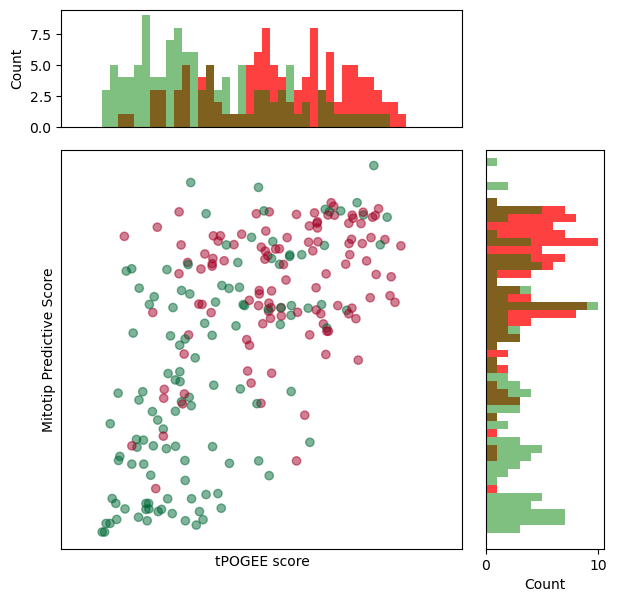

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming model predictions and mitotip_pred scores are already computed
pred_probs = model.predict_proba(X_extended.loc[y_unbiased_from_training.index])[:, 1]
mitotip_scores = mitotip_pred.loc[y_unbiased_from_training.index]
labels = y_unbiased_from_training

# Create a figure with a grid of subplots (3x3) to accommodate scatter and marginal histograms
fig = plt.figure(figsize=(7, 7))
grid = plt.GridSpec(4, 4, hspace=0.2, wspace=0.2)

# Main scatter plot
main_ax = fig.add_subplot(grid[1:4, 0:3])
scatter = main_ax.scatter(pred_probs, mitotip_scores, c=labels, cmap="RdYlGn_r", alpha=0.5)
main_ax.set_xlabel('tPOGEE score')
main_ax.set_ylabel('Mitotip Predictive Score')
plt.xlim(0, 1)

# Marginal histograms on the x-axis (for predicted probabilities)
x_hist = fig.add_subplot(grid[0, 0:3], sharex=main_ax)
x_hist.hist(pred_probs[labels == 1], bins=np.linspace(0,1,51), color='r', alpha=0.75, label='Pathogenic (y=1)')
x_hist.hist(pred_probs[labels == 0], bins=np.linspace(0,1,51), color='g', alpha=0.5, label='Benign (y=0)')
x_hist.set_ylabel('Count')
x_hist.set_xticks([])  # Remove x-axis ticks

# Marginal histograms on the y-axis (for Mitotip predictive scores)
y_hist = fig.add_subplot(grid[1:4, 3], sharey=main_ax)
y_hist.hist(mitotip_scores[labels == 1], bins=np.linspace(0, 21,51), color='r', orientation='horizontal', alpha=0.75, label='Pathogenic (y=1)')
y_hist.hist(mitotip_scores[labels == 0], bins=np.linspace(0, 21,51), color='g', orientation='horizontal', alpha=0.5, label='Benign (y=0)')
y_hist.set_xlabel('Count')
y_hist.set_yticks([])  # Remove y-axis ticks
plt.ylim(0, 21)


# Display the plot
plt.show()

In [ ]:
# 5-repeated 10-fold cross validation on training set (Dataset 1 and 2)
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=777)
training_cross_validation = cross_validate(
    model, X_extended.loc[y_train.index], y_train, cv=kf,
    return_estimator=True, scoring=binary_auROC,
    error_score="raise", verbose=99
)
training_cross_validation

[CV] START .....................................................................
[CV] END ......................................., score=0.834 total time=  55.0s
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:   55.0s
[CV] START .....................................................................
[CV] END ......................................., score=0.787 total time=  53.5s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:  1.8min
[CV] START .....................................................................
[CV] END ......................................., score=0.761 total time=  54.7s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:  2.7min
[CV] START .....................................................................
[CV] END ......................................., score=0.810 total time=  55.5s
[Parallel(n_jobs=1)]: Done   4 tasks      | elapsed:  3.6min
[CV] START .....................................................................
[CV] END ..................

{'fit_time': array([54.870996  , 53.33462453, 54.52313995, 55.43846607, 55.12926173,
        55.11810303, 53.66042709, 55.01655674, 53.93030953, 56.01910734,
        53.60256052, 53.75116825, 55.24576354, 55.10158205, 54.09683681,
        54.543993  , 54.47820115, 54.68040442, 55.99662018, 54.99993467,
        54.30087805, 54.6897018 , 55.36615443, 55.97797298, 55.2582128 ,
        54.58630276, 55.79791856, 55.16221786, 55.50598264, 54.54638648,
        54.06375074, 55.27569199, 55.42620611, 54.65481615, 54.4883585 ,
        54.79810095, 53.84660435, 55.24674678, 55.45447779, 55.0117619 ,
        54.25524592, 54.56860495, 55.63188529, 55.38063598, 55.64363384,
        55.79370785, 55.81697464, 55.3405118 , 55.063802  , 55.0389297 ]),
 'score_time': array([0.1247561 , 0.12239099, 0.12768316, 0.10819364, 0.1240418 ,
        0.126719  , 0.11962533, 0.1318469 , 0.1254468 , 0.1373775 ,
        0.15041995, 0.12262774, 0.13352561, 0.1167326 , 0.11887336,
        0.12474799, 0.11483002, 0.1341

In [ ]:
cv_df = pd.DataFrame()

for i, (estimator, (cv_train, cv_test)) in enumerate(zip(training_cross_validation["estimator"], kf.split( X_extended.loc[y_train.index], y_train))):
    cv_test_ids = y_train.index[cv_test]
    cv_test_ids = cv_test_ids[cv_test_ids.isin(y_unbiased_from_training.index)] # we remove variants present in the mitotip training set from each test fold to have an unbiased evaluation
    cv_df.loc[i, "random_ap"] = y_train.loc[cv_test_ids].mean()
    cv_df.loc[i, "tPOGEE_auc"] = roc_auc_score(y_train.loc[cv_test_ids], estimator.predict_proba(X_extended.loc[cv_test_ids])[:,1])
    cv_df.loc[i, "mitotip_auc"] = roc_auc_score(y_train.loc[cv_test_ids], mitotip_pred.loc[cv_test_ids, "Predictive score"])
    cv_df.loc[i, "tPOGEE_ap"] = average_precision_score(y_train.loc[cv_test_ids], estimator.predict_proba(X_extended.loc[cv_test_ids])[:,1])
    cv_df.loc[i, "mitotip_ap"] = average_precision_score(y_train.loc[cv_test_ids], mitotip_pred.loc[cv_test_ids, "Predictive score"])

cv_df

,random_ap,tPOGEE_auc,mitotip_auc,tPOGEE_ap,mitotip_ap
0,0.578947,0.784091,0.715909,0.827133,0.796996
1,0.464286,0.728205,0.682051,0.722606,0.665509
2,0.407407,0.767045,0.772727,0.624773,0.650938
3,0.466667,0.767857,0.767857,0.669140,0.666327
4,0.521739,0.878788,0.742424,0.901449,0.675841
5,0.461538,0.726190,0.797619,0.663695,0.669665
6,0.444444,0.788889,0.697222,0.745479,0.581460
7,0.619048,0.826923,0.701923,0.908257,0.707774
8,0.478261,0.643939,0.734848,0.587943,0.627622
9,0.476190,0.927273,0.809091,0.898770,0.836538


In [93]:
cv_df.mean()

tPOGEE_auc     0.777988
mitotip_auc    0.746441
tPOGEE_ap      0.772773
mitotip_ap     0.700960
dtype: float64

In [84]:
stats.wilcoxon(cv_df.tPOGEE_auc, cv_df.mitotip_auc)

WilcoxonResult(statistic=np.float64(352.5), pvalue=np.float64(0.025209739094246147))

In [87]:
(cv_df.tPOGEE_auc - cv_df.mitotip_auc).mean()

np.float64(0.03154688908604994)

In [89]:
stats.wilcoxon(cv_df.tPOGEE_ap, cv_df.mitotip_ap)

WilcoxonResult(statistic=np.float64(209.0), pvalue=np.float64(1.367585375788849e-05))

In [90]:
(cv_df.tPOGEE_ap - cv_df.mitotip_ap).mean()

np.float64(0.0718122800627966)

In [95]:
(cv_df.tPOGEE_ap>cv_df.mitotip_ap).mean()

np.float64(0.72)

In [96]:
(cv_df.tPOGEE_auc>cv_df.mitotip_auc).mean()

np.float64(0.6)